In [72]:
import pandas as pd

data = [
    {"waste_type": "general", "disposal_method": "landfill", "unit": "kg", "emission_factor": 0.78},
    {"waste_type": "food", "disposal_method": "landfill", "unit": "kg", "emission_factor": 1.4},
    {"waste_type": "food", "disposal_method": "composting", "unit": "kg", "emission_factor": 0.2},
    {"waste_type": "plastic", "disposal_method": "landfill", "unit": "kg", "emission_factor": 2.5},
    {"waste_type": "plastic", "disposal_method": "recycling", "unit": "kg", "emission_factor": -0.4},
    {"waste_type": "paper", "disposal_method": "landfill", "unit": "kg", "emission_factor": 1.0},  # proxy for paper landfill
    {"waste_type": "paper", "disposal_method": "recycling", "unit": "kg", "emission_factor": -0.4},
]

df = pd.DataFrame(data)

# Save file
df.to_csv("waste_emission_factors.csv", index=False)

print(" waste_emission_factors.csv created with recycling included")
print(df)


 waste_emission_factors.csv created with recycling included
  waste_type disposal_method unit  emission_factor
0    general        landfill   kg             0.78
1       food        landfill   kg             1.40
2       food      composting   kg             0.20
3    plastic        landfill   kg             2.50
4    plastic       recycling   kg            -0.40
5      paper        landfill   kg             1.00
6      paper       recycling   kg            -0.40


In [73]:
import pandas as pd

waste = pd.read_csv("waste.csv")

print("Unique disposal methods in waste.csv:")
print(waste["disposal_method"].unique())

print("\nCount of recycling rows:")
print(waste[waste["disposal_method"] == "recycling"].shape[0])


Unique disposal methods in waste.csv:
['composting' 'recycling' 'landfill']

Count of recycling rows:
49


In [74]:
import pandas as pd
import random

businesses = [
    {"business_id": "B0001", "business_type": "Bakery"},
    {"business_id": "B0002", "business_type": "Restaurant"},
    {"business_id": "B0003", "business_type": "Supermarket"},
]

waste_types = ["food", "plastic", "paper"]

records = []
months = pd.date_range("2024-01-01", "2024-12-01", freq="MS")

for biz in businesses:
    for month in months:
        for w in waste_types:
            # landfill / composting logic
            if w == "food":
                method = random.choice(["landfill", "composting"])
            elif w in ["plastic", "paper"]:
                method = random.choice(["landfill", "recycling"])
            else:
                method = "landfill"

            records.append({
                "business_id": biz["business_id"],
                "business_type": biz["business_type"],
                "date": month.strftime("%Y-%m"),
                "waste_type": w,
                "disposal_method": method,
                "weight_kg": round(random.uniform(10, 100), 2)
            })

df_waste = pd.DataFrame(records)
df_waste.to_csv("waste.csv", index=False)
print("waste.csv created with", len(df_waste), "rows")
print(df_waste.head(10))


waste.csv created with 108 rows
  business_id business_type     date waste_type disposal_method  weight_kg
0       B0001        Bakery  2024-01       food      composting      94.59
1       B0001        Bakery  2024-01    plastic        landfill      96.46
2       B0001        Bakery  2024-01      paper       recycling      32.99
3       B0001        Bakery  2024-02       food        landfill      56.78
4       B0001        Bakery  2024-02    plastic       recycling      76.73
5       B0001        Bakery  2024-02      paper       recycling      72.20
6       B0001        Bakery  2024-03       food      composting      82.13
7       B0001        Bakery  2024-03    plastic       recycling      61.10
8       B0001        Bakery  2024-03      paper       recycling      23.37
9       B0001        Bakery  2024-04       food        landfill      25.80


In [75]:
df_waste.head()

,business_id,business_type,date,waste_type,disposal_method,weight_kg
0,B0001,Bakery,2024-01,food,composting,94.59
1,B0001,Bakery,2024-01,plastic,landfill,96.46
2,B0001,Bakery,2024-01,paper,recycling,32.99
3,B0001,Bakery,2024-02,food,landfill,56.78
4,B0001,Bakery,2024-02,plastic,recycling,76.73


In [76]:
import pandas as pd

# --- LOAD DATA ---
waste = pd.read_csv("waste.csv")
factors = pd.read_csv("waste_emission_factors.csv")

# --- MERGE DATASETS ---
df_waste = waste.merge(
    factors,
    how="left",
    on=["waste_type", "disposal_method"]
)

# --- CALCULATE EMISSIONS ---
df_waste["emissions_kgCO2e"] = df_waste["weight_kg"] * df_waste["emission_factor"]

# --- SAVE OUTPUT ---
df_waste.to_csv("waste_emissions_summary.csv", index=False)

print("waste_emissions_summary.csv created with", len(df_waste), "rows")
print(df_waste.head(10))


waste_emissions_summary.csv created with 108 rows
  business_id business_type     date waste_type disposal_method  weight_kg  \
0       B0001        Bakery  2024-01       food      composting      94.59   
1       B0001        Bakery  2024-01    plastic        landfill      96.46   
2       B0001        Bakery  2024-01      paper       recycling      32.99   
3       B0001        Bakery  2024-02       food        landfill      56.78   
4       B0001        Bakery  2024-02    plastic       recycling      76.73   
5       B0001        Bakery  2024-02      paper       recycling      72.20   
6       B0001        Bakery  2024-03       food      composting      82.13   
7       B0001        Bakery  2024-03    plastic       recycling      61.10   
8       B0001        Bakery  2024-03      paper       recycling      23.37   
9       B0001        Bakery  2024-04       food        landfill      25.80   

  unit  emission_factor  emissions_kgCO2e  
0   kg              0.2            18.918  
1  

In [77]:
df_waste.head(10)

,business_id,business_type,date,waste_type,disposal_method,weight_kg,unit,emission_factor,emissions_kgCO2e
0,B0001,Bakery,2024-01,food,composting,94.59,kg,0.2,18.918
1,B0001,Bakery,2024-01,plastic,landfill,96.46,kg,2.5,241.150
2,B0001,Bakery,2024-01,paper,recycling,32.99,kg,-0.4,-13.196
3,B0001,Bakery,2024-02,food,landfill,56.78,kg,1.4,79.492
4,B0001,Bakery,2024-02,plastic,recycling,76.73,kg,-0.4,-30.692
5,B0001,Bakery,2024-02,paper,recycling,72.20,kg,-0.4,-28.880
6,B0001,Bakery,2024-03,food,composting,82.13,kg,0.2,16.426
7,B0001,Bakery,2024-03,plastic,recycling,61.10,kg,-0.4,-24.440
8,B0001,Bakery,2024-03,paper,recycling,23.37,kg,-0.4,-9.348
9,B0001,Bakery,2024-04,food,landfill,25.80,kg,1.4,36.120


In [78]:
df_waste["disposal_method"].unique()


array(['composting', 'landfill', 'recycling'], dtype=object)

In [79]:
df_waste.shape

(108, 9)

In [80]:
df_waste.head()

,business_id,business_type,date,waste_type,disposal_method,weight_kg,unit,emission_factor,emissions_kgCO2e
0,B0001,Bakery,2024-01,food,composting,94.59,kg,0.2,18.918
1,B0001,Bakery,2024-01,plastic,landfill,96.46,kg,2.5,241.150
2,B0001,Bakery,2024-01,paper,recycling,32.99,kg,-0.4,-13.196
3,B0001,Bakery,2024-02,food,landfill,56.78,kg,1.4,79.492
4,B0001,Bakery,2024-02,plastic,recycling,76.73,kg,-0.4,-30.692


In [81]:
# Save cleaned waste dataset
df_waste.to_csv("waste_emissions_summary.csv", index=False)

# Download to your computer
from google.colab import files
files.download("waste_emissions_summary.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

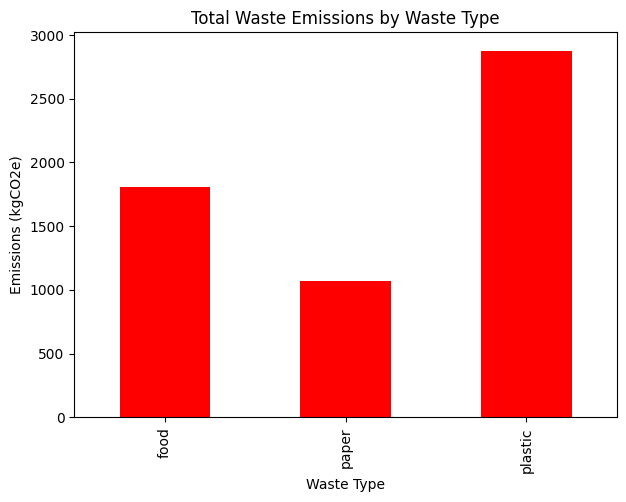

In [82]:
import matplotlib.pyplot as plt

waste_summary = df_waste.groupby("waste_type")["emissions_kgCO2e"].sum()

waste_summary.plot(kind="bar", figsize=(7,5), color= 'red')
plt.title("Total Waste Emissions by Waste Type")
plt.xlabel("Waste Type")
plt.ylabel("Emissions (kgCO2e)")
plt.show()


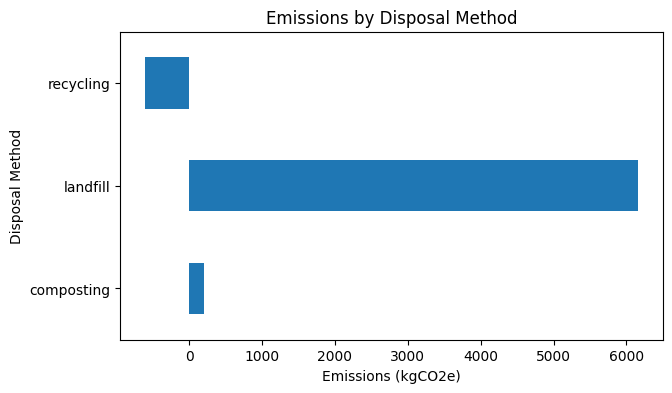

In [83]:
method_summary = df_waste.groupby("disposal_method")["emissions_kgCO2e"].sum()

method_summary.plot(kind="barh", figsize=(7,4))
plt.title("Emissions by Disposal Method")
plt.xlabel("Emissions (kgCO2e)")
plt.ylabel("Disposal Method")
plt.show()


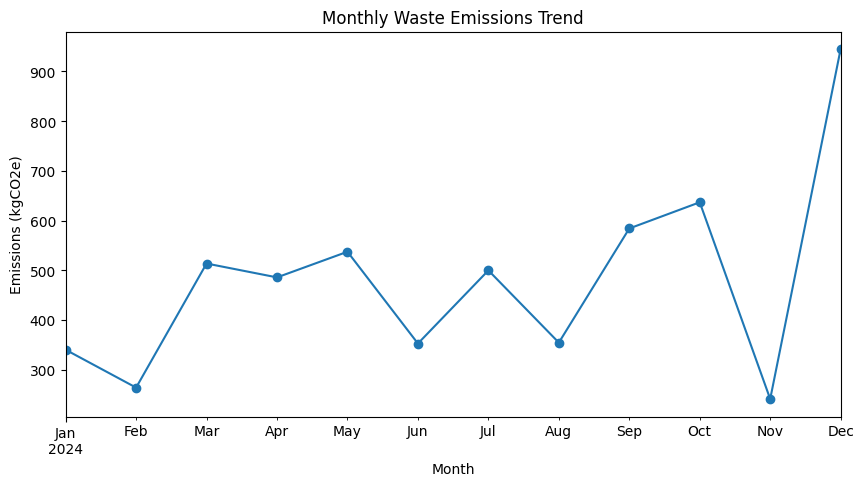

In [84]:
df_waste["date"] = pd.to_datetime(df_waste["date"])

monthly_trend = df_waste.groupby(df_waste["date"].dt.to_period("M"))["emissions_kgCO2e"].sum()

monthly_trend.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Monthly Waste Emissions Trend")
plt.xlabel("Month")
plt.ylabel("Emissions (kgCO2e)")
plt.show()


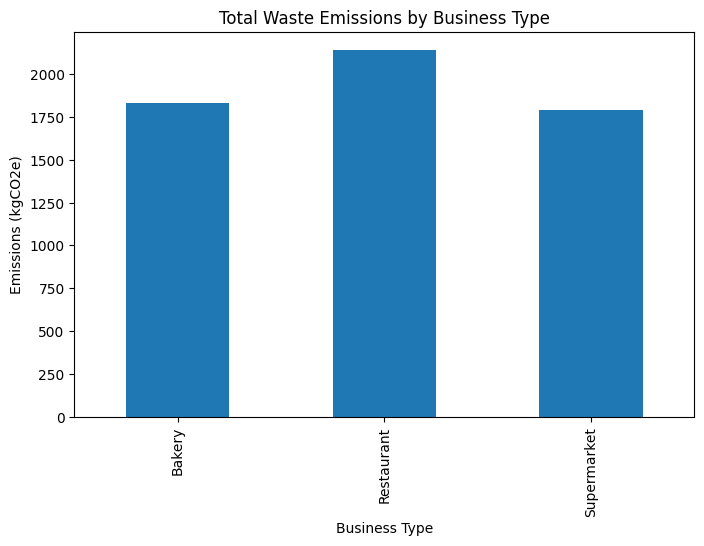

In [85]:
business_summary = df_waste.groupby("business_type")["emissions_kgCO2e"].sum()

business_summary.plot(kind="bar", figsize=(8,5))
plt.title("Total Waste Emissions by Business Type")
plt.xlabel("Business Type")
plt.ylabel("Emissions (kgCO2e)")
plt.show()


In [86]:
df_waste['business_type'].unique()

array(['Bakery', 'Restaurant', 'Supermarket'], dtype=object)